# Proyecciones a partir de embeddings generados por modelos fundacionales



In [29]:
from pathlib import Path
from random import seed as set_python_seed
import sys
import os

import torch
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf


REPO_ROOT = "../"
SRC_DIR = "../src/"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from foundation_ts.data import load_dataicann, make_dataicann_windows
from foundation_ts.models import build_model



In [30]:
def setup_seed(seed: int) -> None:
    """Set the base seed for reproducible examples."""
    set_python_seed(seed)
    torch.manual_seed(seed)

import os

with initialize_config_dir(version_base=None, config_dir=os.path.join(Path.cwd(),f"{REPO_ROOT}/configs")):
    cfg = compose(config_name="config")

setup_seed(cfg.project.seed)

print(OmegaConf.to_yaml(cfg))

project:
  name: foundation-ts
  seed: 42
data:
  path: data/raw/dataicann
  target: null
  frequency: null
  window_size: 400
  stride: 100
model:
  name: moment
  params:
    model_id: AutonLab/MOMENT-1-large
    task_name: embedding
    output_key: embeddings
    channel_first: false
    device: cuda
    model_kwargs: {}
training:
  device: auto
  batch_size: null
  max_epochs: null
  optimizer: null
  learning_rate: null
evaluation:
  params: {}



In [31]:
output_dir = Path.cwd()
data_path = Path(str(cfg.data.path))
if not data_path.is_absolute():
    data_path = REPO_ROOT / data_path

mat_file_path = data_path if data_path.suffix == ".mat" else data_path / "dataicann.mat"

window_size = int(cfg.data.get("window_size", 512))
stride = int(cfg.data.get("stride", window_size))

print(f"Data path: {mat_file_path}")
print(f"Window size: {window_size}")
print(f"Stride: {stride}")

Data path: ../data/raw/dataicann/dataicann.mat
Window size: 400
Stride: 100


In [32]:
df = load_dataicann(mat_file_path)
df = df[~df["experiment"].isin([7,8])]

windows = make_dataicann_windows(
    df,
    window_size=window_size,
    stride=stride,
)
# Eliminamos los graduales


x = torch.as_tensor(windows, dtype=torch.float32)

print(f"DataFrame: {df.shape}")
print(f"Input windows: {x.shape}")
df.head()

DataFrame: (139776, 6)
Input windows: torch.Size([1394, 400, 5])


,experiment,ac,ax,ay,ir,is
0,0,0.546812,0.214863,-0.193433,0.038366,-0.740754
1,0,0.264445,0.052439,-0.180099,0.051696,-0.738379
2,0,0.154454,-0.057047,0.052987,0.068516,-0.730861
3,0,0.075264,-0.119849,0.111473,0.097124,-0.724808
4,0,-0.320132,-0.201018,-0.008996,0.134691,-0.725660


In [33]:
model_params = OmegaConf.to_container(cfg.model.params, resolve=True)
model = build_model(cfg.model.name, model_params)

y = model.predict(x,batch_size=32)
print(y.shape)

/home/diego/miniforge3/envs/foundation-ts/lib/python3.11/site-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


torch.Size([1394, 1024])


Embeddings originales: (1394, 1024)
Embeddings PCA: (1394, 2)
Varianza explicada: [0.23483953 0.1774807 ]
Varianza explicada total: 0.412


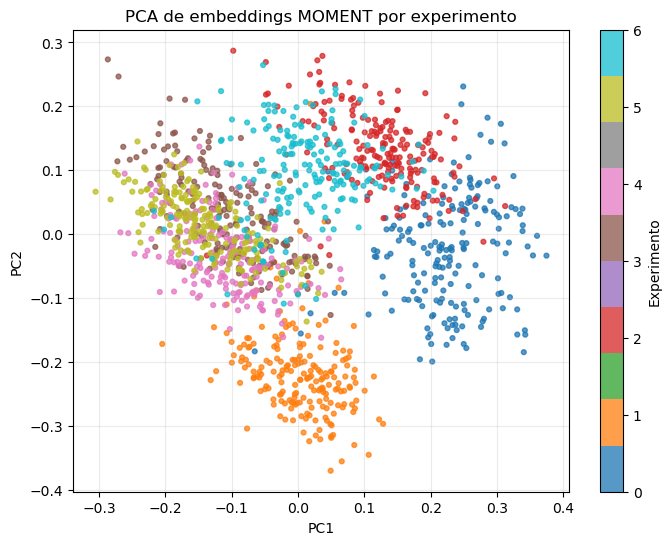

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Pasar embeddings de torch a numpy
embeddings = y.detach().cpu().numpy() if hasattr(y, "detach") else np.asarray(y)

pca = PCA(n_components=2, random_state=cfg.project.seed)
embeddings_pca = pca.fit_transform(embeddings)

print(f"Embeddings originales: {embeddings.shape}")
print(f"Embeddings PCA: {embeddings_pca.shape}")
print(f"Varianza explicada: {pca.explained_variance_ratio_}")
print(f"Varianza explicada total: {pca.explained_variance_ratio_.sum():.3f}")
experiment_ids = df["experiment"].to_numpy()

# Un id por ventana, usando el inicio de cada ventana
window_experiments = experiment_ids[
    np.arange(0, len(df) - window_size + 1, stride)
]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    embeddings_pca[:, 0],
    embeddings_pca[:, 1],
    c=window_experiments,
    cmap="tab10",
    s=12,
    alpha=0.75,
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA de embeddings MOMENT por experimento")
plt.colorbar(scatter, label="Experimento")
plt.grid(alpha=0.25)
plt.show()

Embeddings originales: (1394, 1024)
Embeddings t-SNE: (1394, 2)


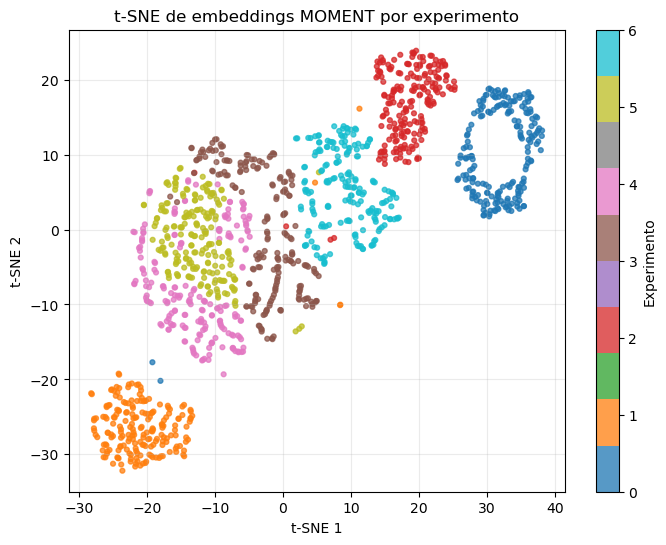

In [35]:
from sklearn.manifold import TSNE

# Pasar embeddings de torch a numpy
embeddings = y.detach().cpu().numpy() if hasattr(y, "detach") else np.asarray(y)

# Si MOMENT devuelve mas de 2 dimensiones, aplanamos todo excepto batch
# Ejemplo: (n_windows, n_tokens, hidden_dim) -> (n_windows, n_tokens * hidden_dim)
if embeddings.ndim > 2:
    embeddings = embeddings.reshape(embeddings.shape[0], -1)

tsne = TSNE(
    n_components=2,
    perplexity=100,
    learning_rate="auto",
    init="pca",
    random_state=cfg.project.seed,
)

embeddings_tsne = tsne.fit_transform(embeddings)

print(f"Embeddings originales: {embeddings.shape}")
print(f"Embeddings t-SNE: {embeddings_tsne.shape}")
experiment_ids = df["experiment"].to_numpy()

# Un id por ventana, usando el inicio de cada ventana
window_experiments = experiment_ids[
    np.arange(0, len(df) - window_size + 1, stride)
]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    embeddings_tsne[:, 0],
    embeddings_tsne[:, 1],
    c=window_experiments,
    cmap="tab10",
    s=12,
    alpha=0.75,
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE de embeddings MOMENT por experimento")
plt.colorbar(scatter, label="Experimento")
plt.grid(alpha=0.25)
plt.show()